# Week 4: Introduction to Machine Learning

## Learning from data, testing fairly, and deciding whether a model is useful

This notebook is designed for Google Colab and Jupyter. It is fully self-contained. All datasets used in the notebook are generated inside the notebook, so you do not need to download external files.

### By the end of this notebook, you should be able to

1. Explain the difference between ordinary programming and machine learning.
2. Identify rows, features, targets, `X`, and `y`.
3. Distinguish classification, regression, and clustering.
4. Inspect a dataset before modelling.
5. Explain missing values, encoding, and scaling.
6. Create a train/test split.
7. Build a simple baseline.
8. Train and evaluate classification models.
9. Explain accuracy, precision, recall, F1, and the confusion matrix.
10. Calculate common regression metrics.
11. Recognize underfitting, reasonable fit, and overfitting.
12. Detect common forms of data leakage.
13. Use validation and cross-validation.
14. Inspect model errors before deciding whether a model is useful.

### How to use this notebook

For each section:

1. Read the explanation.
2. Predict what you think the code will do.
3. Run the cell.
4. Inspect the output.
5. Explain the result in your own words.

The goal is not to memorize scikit-learn commands. The goal is to understand the full machine learning workflow.

## 0. The complete machine learning workflow

A useful mental model is:

**Problem -> Prediction unit -> Data audit -> Split -> Preprocess -> Baseline -> Train -> Evaluate -> Inspect errors -> Decide**

The model is only one part of the system.

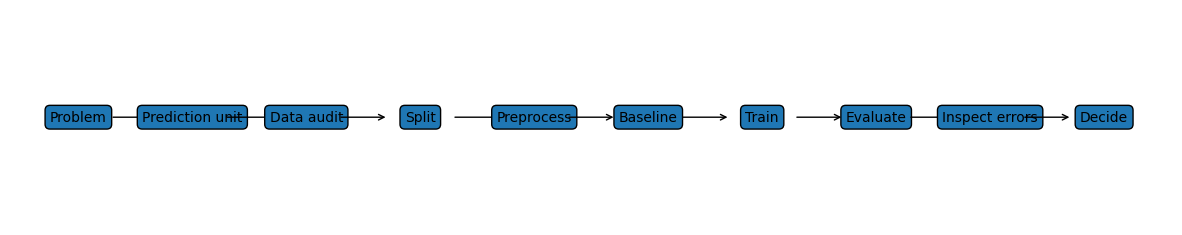

In [45]:
import matplotlib.pyplot as plt

steps = [
    "Problem", "Prediction unit", "Data audit", "Split", "Preprocess",
    "Baseline", "Train", "Evaluate", "Inspect errors", "Decide"
]

fig, ax = plt.subplots(figsize=(15, 2.8))
ax.axis("off")

for i, step in enumerate(steps):
    x = i
    ax.text(
        x, 0.5, step,
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.35")
    )
    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x + 0.72, 0.5),
            xytext=(x + 0.28, 0.5),
            arrowprops=dict(arrowstyle="->")
        )

ax.set_xlim(-0.6, len(steps) - 0.4)
ax.set_ylim(0, 1)
plt.show()

# Part A: What machine learning actually does

## 1. Ordinary programming: we write the rules

In ordinary programming, the programmer explicitly writes the decision rule.

Run the example below.

In [48]:
temperature = 87

if temperature > 80:
    print("Fan ON")
else:
    print("Fan OFF")

Fan ON


### Think

Who created the rule `temperature > 80`?

The programmer did.

This approach works well when rules are clear, stable, and manageable.

Machine learning becomes useful when the rules are difficult to write manually, but we have examples from which a system can learn patterns.

## 2. A tiny machine learning example

Suppose we have historical motor observations. For each observation, we know the temperature, vibration, current, and whether the motor was faulty.

Instead of writing every possible fault rule ourselves, we can show a model examples and ask it to learn a pattern.

In [49]:
import numpy as np
import pandas as pd

tiny_motor_data = pd.DataFrame({
    "temperature": [65, 72, 78, 91, 95, 88, 69, 82],
    "vibration":   [0.20, 0.25, 0.31, 0.83, 0.91, 0.76, 0.22, 0.55],
    "current":     [3.8, 4.1, 4.4, 6.9, 7.3, 6.4, 3.9, 5.4],
    "fault":       [0, 0, 0, 1, 1, 1, 0, 1]
})

tiny_motor_data

,temperature,vibration,current,fault
0,65,0.20,3.8,0
1,72,0.25,4.1,0
2,78,0.31,4.4,0
3,91,0.83,6.9,1
4,95,0.91,7.3,1
5,88,0.76,6.4,1
6,69,0.22,3.9,0
7,82,0.55,5.4,1


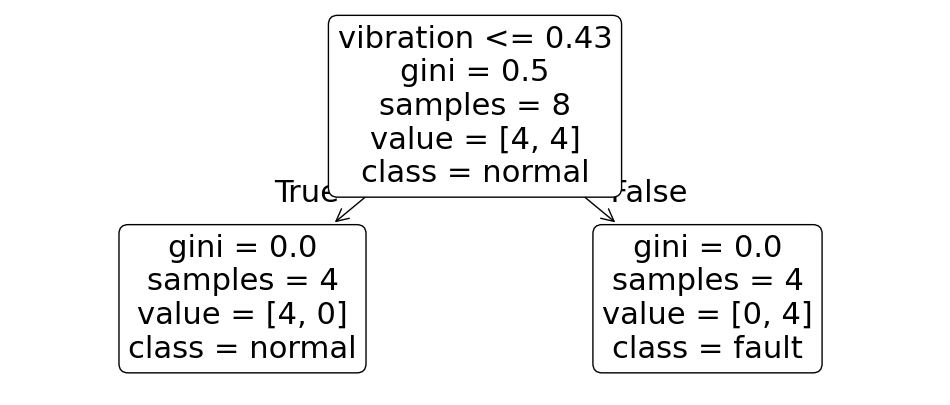

In [50]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

X_tiny = tiny_motor_data[["temperature", "vibration", "current"]]
y_tiny = tiny_motor_data["fault"]

tiny_tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tiny_tree.fit(X_tiny, y_tiny)

plt.figure(figsize=(12, 5))
plot_tree(
    tiny_tree,
    feature_names=X_tiny.columns,
    class_names=["normal", "fault"],
    filled=False,
    rounded=True
)
plt.show()

### What happened?

The model was not given a complete set of fault rules. It examined examples and learned split rules that helped separate normal observations from fault observations.

Different models learn different internal structures:

- Decision trees learn split rules.
- Logistic regression learns coefficients.
- Neural networks learn many weights.

In machine learning, "learning" means adjusting internal parameters or structure so that outputs fit useful patterns in examples.

## 3. The real goal is generalisation

A useful model should work on relevant cases it has not simply memorized.

A good analogy is a student:

- **Memorisation:** remembers exact answers from previous questions.
- **Generalisation:** understands the pattern well enough to solve a new but related question.

Training performance tells us how well a model handled examples it was allowed to learn from.

Unseen data tells us whether the learned pattern transfers.

# Part B: Understanding the dataset

## 4. Create our main motor dataset

We will use a synthetic motor monitoring dataset throughout much of this notebook.

### Prediction unit

One row represents one 10-second sensor window from one motor.

### Features

The model may use:

- temperature
- vibration
- current
- RPM
- operating hours

### Target

We will predict whether the sensor window represents:

- `0`: normal
- `1`: fault

Because this target is a category, this is a **classification** problem.

In [51]:
rng = np.random.default_rng(42)

n = 700

temperature = rng.normal(75, 9, n)
vibration = rng.normal(0.35, 0.12, n)
current = rng.normal(4.8, 0.9, n)
rpm = rng.normal(1450, 130, n)
operating_hours = rng.uniform(50, 5000, n)

risk = (
    0.09 * (temperature - 75)
    + 4.8 * (vibration - 0.35)
    + 0.55 * (current - 4.8)
    - 0.002 * (rpm - 1450)
    + 0.00035 * (operating_hours - 2500)
    + rng.normal(0, 0.9, n)
)

fault = (risk > 2.4).astype(int)

motor_df = pd.DataFrame({
    "temperature": temperature.round(2),
    "vibration": vibration.round(3),
    "current": current.round(2),
    "rpm": rpm.round(0).astype(int),
    "operating_hours": operating_hours.round(0).astype(int),
    "fault": fault
})

motor_df

,temperature,vibration,current,rpm,operating_hours,fault
0,77.74,0.484,5.86,1483,2104,0
1,65.64,0.321,4.51,1227,663,0
2,81.75,0.226,4.62,1357,2082,0
3,83.47,0.343,4.36,1550,2807,0
4,57.44,0.476,4.28,1414,4657,0
...,...,...,...,...,...,...
695,67.96,0.573,5.51,1538,2596,0
696,54.12,0.422,5.58,1523,3570,0
697,66.33,0.328,4.08,1417,2544,0
698,66.76,0.419,3.17,1525,4527,0


In [6]:
print("Shape:", motor_df.shape)
print()
print("Class counts:")
print(motor_df["fault"].value_counts())
print()
print("Class proportions:")
print(motor_df["fault"].value_counts(normalize=True).round(3))

Shape: (700, 6)

Class counts:
fault
0    675
1     25
Name: count, dtype: int64

Class proportions:
fault
0    0.964
1    0.036
Name: proportion, dtype: float64


## 5. Rows, features, target, X, and y

A dataset is recorded experience.

- A **row** is one example.
- A **feature** is information the model is allowed to use.
- A **target** is the answer we want the model to predict in supervised learning.

The standard notation is:

- `X` = features
- `y` = target

In [7]:
X = motor_df.drop(columns="fault")
y = motor_df["fault"]

print("X contains the features:")
display(X.head())

print("\ny contains the target:")
display(y.head())

X contains the features:


,temperature,vibration,current,rpm,operating_hours
0,77.74,0.484,5.86,1483,2104
1,65.64,0.321,4.51,1227,663
2,81.75,0.226,4.62,1357,2082
3,83.47,0.343,4.36,1550,2807
4,57.44,0.476,4.28,1414,4657



y contains the target:


0    0
1    0
2    0
3    0
4    0
Name: fault, dtype: int64

When you later see:

```python
model.fit(X_train, y_train)
```

read it as:

> Learn a relationship between the training features and their known answers.

# Part C: Classification, regression, and clustering

## 6. Classification

Classification predicts a category.

Examples:

- spam or not spam
- normal or fault
- benign or malicious
- crop disease category

Our motor fault problem is classification because the output is a class label.

## 7. Regression

Regression predicts a continuous number.

Examples:

- house price
- electricity demand
- travel time
- battery life remaining

The next cell creates a tiny synthetic electricity demand dataset and fits a regression model.

In [8]:
from sklearn.linear_model import LinearRegression

days = np.arange(1, 31)
temperature_demo = 24 + 5 * np.sin(days / 5)
demand_demo = 30 + 0.8 * temperature_demo + 0.12 * days + rng.normal(0, 1.5, len(days))

reg_demo = pd.DataFrame({
    "day": days,
    "temperature": temperature_demo,
    "demand_MW": demand_demo
})

X_reg_demo = reg_demo[["day", "temperature"]]
y_reg_demo = reg_demo["demand_MW"]

reg_model_demo = LinearRegression()
reg_model_demo.fit(X_reg_demo, y_reg_demo)

reg_demo["prediction_MW"] = reg_model_demo.predict(X_reg_demo)
reg_demo.head()

,day,temperature,demand_MW,prediction_MW
0,1,24.993347,47.989164,50.094353
1,2,25.947092,54.531405,51.068200
2,3,26.823212,51.775157,51.974324
3,4,27.586780,53.125925,52.782253
4,5,28.207355,53.765171,53.465427


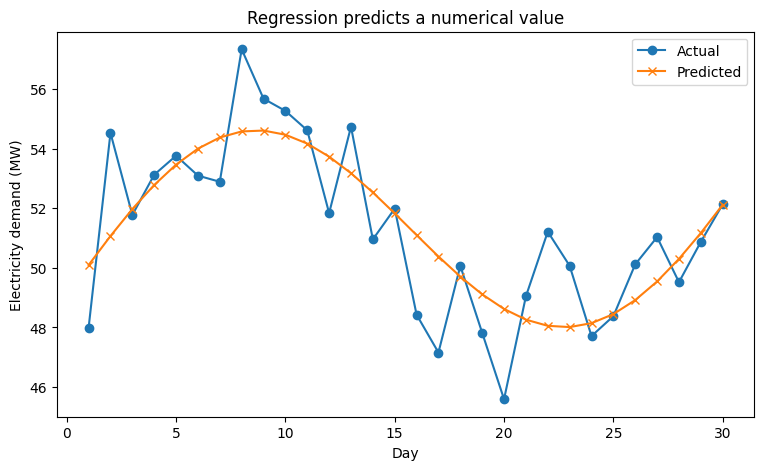

In [9]:
plt.figure(figsize=(9, 5))
plt.plot(reg_demo["day"], reg_demo["demand_MW"], marker="o", label="Actual")
plt.plot(reg_demo["day"], reg_demo["prediction_MW"], marker="x", label="Predicted")
plt.xlabel("Day")
plt.ylabel("Electricity demand (MW)")
plt.title("Regression predicts a numerical value")
plt.legend()
plt.show()

## 8. Clustering

Clustering is a common unsupervised learning task.

There is no target column. The algorithm looks for structure or groups in the data.

Below, we create three groups of sensor operating conditions and ask k-means to discover clusters.

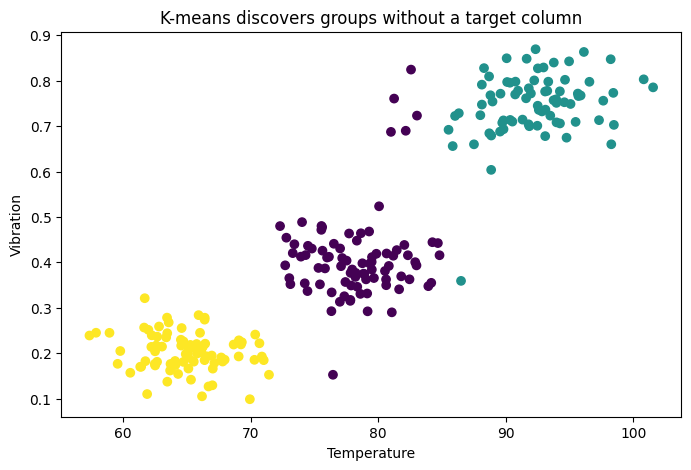

In [10]:
from sklearn.cluster import KMeans

cluster_a = rng.normal(loc=[65, 0.20], scale=[3.5, 0.04], size=(80, 2))
cluster_b = rng.normal(loc=[78, 0.40], scale=[3.5, 0.05], size=(80, 2))
cluster_c = rng.normal(loc=[92, 0.75], scale=[3.5, 0.06], size=(80, 2))

cluster_data = np.vstack([cluster_a, cluster_b, cluster_c])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(cluster_data)

plt.figure(figsize=(8, 5))
plt.scatter(cluster_data[:, 0], cluster_data[:, 1], c=cluster_labels)
plt.xlabel("Temperature")
plt.ylabel("Vibration")
plt.title("K-means discovers groups without a target column")
plt.show()

### Quick check

Decide the learning type before revealing the answers.

1. Predict crop disease category
2. Predict next-month electricity demand
3. Group customers with similar behaviour
4. Predict whether a login is malicious
5. Predict travel time in minutes
6. Discover operating modes in sensor data

In [11]:
answers = {
    1: "Classification",
    2: "Regression",
    3: "Clustering",
    4: "Classification",
    5: "Regression",
    6: "Clustering"
}

for number, answer in answers.items():
    print(f"{number}. {answer}")

1. Classification
2. Regression
3. Clustering
4. Classification
5. Regression
6. Clustering


# Part D: Data quality before modelling

## 9. A dataset is not ready just because pandas can read it

Real datasets can contain:

- missing values
- invalid values
- duplicate rows
- inconsistent units
- strange text values
- old or irrelevant records

The next DataFrame is deliberately dirty.

In [12]:
dirty_df = pd.DataFrame({
    "time": ["10:00", "10:10", "10:20", "10:20", "10:30", "10:40"],
    "temp_C": [78, -900, 83, 83, "73F", 88],
    "vibration": [4.2, 4.1, np.nan, np.nan, 4.0, 5.6],
    "current_A": [6.8, 6.7, 6.9, 6.9, "?", 7.2],
    "motor_id": ["M01", "M01", "M01", "M01", "M99", "M01"],
    "fault_label": ["normal", "normal", "fault", "fault", "normal", "fault"]
})

dirty_df

,time,temp_C,vibration,current_A,motor_id,fault_label
0,10:00,78,4.2,6.8,M01,normal
1,10:10,-900,4.1,6.7,M01,normal
2,10:20,83,NaN,6.9,M01,fault
3,10:20,83,NaN,6.9,M01,fault
4,10:30,73F,4.0,?,M99,normal
5,10:40,88,5.6,7.2,M01,fault


In [13]:
print("Data types:")
print(dirty_df.dtypes)

print("\nMissing values:")
print(dirty_df.isna().sum())

print("\nDuplicate rows:")
print(dirty_df.duplicated().sum())

Data types:
time            object
temp_C          object
vibration      float64
current_A       object
motor_id        object
fault_label     object
dtype: object

Missing values:
time           0
temp_C         0
vibration      2
current_A      0
motor_id       0
fault_label    0
dtype: int64

Duplicate rows:
1


### Six useful data quality checks

1. **Completeness:** Are required values present?
2. **Validity:** Do values obey domain rules?
3. **Consistency:** Is one concept represented in the same way?
4. **Uniqueness:** Are duplicate records intentional?
5. **Timeliness:** Does the data match the prediction period?
6. **Representativeness:** Does the data resemble the environment where the model will be used?

Cleaning is not a ritual. Every cleaning choice changes the evidence.

## 10. Missing data

A missing value is not always just an empty cell.

For a sensor, a missing reading could mean:

- sensor failure
- lost network connection
- device was switched off
- logging software failed

Sometimes the fact that a value is missing can itself be informative.

In [14]:
missing_demo = pd.DataFrame({
    "temperature": [72, 74, np.nan, 81, 83],
    "vibration": [0.20, np.nan, 0.44, 0.51, 0.57]
})

print("Original data:")
display(missing_demo)

print("After dropping rows with any missing value:")
display(missing_demo.dropna())

imputed = missing_demo.fillna(missing_demo.mean(numeric_only=True))
print("After simple mean imputation:")
display(imputed)

Original data:


,temperature,vibration
0,72.0,0.20
1,74.0,NaN
2,NaN,0.44
3,81.0,0.51
4,83.0,0.57


After dropping rows with any missing value:


,temperature,vibration
0,72.0,0.20
3,81.0,0.51
4,83.0,0.57


After simple mean imputation:


,temperature,vibration
0,72.0,0.20
1,74.0,0.43
2,77.5,0.44
3,81.0,0.51
4,83.0,0.57


There is no universal rule saying "delete every row with a missing value."

The correct choice depends on why values are missing and how the model will be used.

## 11. Categorical variables must become numbers carefully

Suppose motor type is:

- Type A
- Type B
- Type C

Encoding these as `A=1`, `B=2`, `C=3` can accidentally suggest an order or numerical spacing that does not exist.

One-hot encoding is often a safer default for nominal categories.

In [15]:
from sklearn.preprocessing import OneHotEncoder

motor_types = pd.DataFrame({
    "motor_type": ["A", "B", "C", "A", "C", "B"]
})

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded = encoder.fit_transform(motor_types[["motor_type"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["motor_type"])
)

display(motor_types)
display(encoded_df)

,motor_type
0,A
1,B
2,C
3,A
4,C
5,B


,motor_type_A,motor_type_B,motor_type_C
0,1.0,0.0,0.0
1,0.0,1.0,0.0
2,0.0,0.0,1.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
5,0.0,1.0,0.0


## 12. Scaling

Some algorithms are sensitive to numerical scale because they use distances or gradients.

Consider:

- age = 22
- income = 10,000,000

A distance-based algorithm may allow the large numerical scale of income to dominate.

Standardisation transforms a value using:

\[
z = \frac{x - \mu}{\sigma}
\]

where:

- \(x\) is the original value
- \(\mu\) is the mean
- \(\sigma\) is the standard deviation

In [16]:
from sklearn.preprocessing import StandardScaler

scale_demo = pd.DataFrame({
    "age": [18, 22, 26, 31, 40],
    "income": [1_200_000, 3_500_000, 7_000_000, 12_000_000, 25_000_000]
})

scaler_demo = StandardScaler()
scaled_values = scaler_demo.fit_transform(scale_demo)

scaled_demo = pd.DataFrame(
    scaled_values,
    columns=["age_scaled", "income_scaled"]
)

print("Original:")
display(scale_demo)

print("Standardised:")
display(scaled_demo.round(3))

Original:


,age,income
0,18,1200000
1,22,3500000
2,26,7000000
3,31,12000000
4,40,25000000


Standardised:


,age_scaled,income_scaled
0,-1.232,-1.010
1,-0.708,-0.738
2,-0.183,-0.324
3,0.472,0.267
4,1.651,1.805


Algorithms such as k-nearest neighbours, k-means, SVMs, and many gradient-based methods can be scale-sensitive.

Decision trees are usually much less sensitive to feature scale.

# Part E: Training and testing fairly

## 13. Training data is not the exam

To estimate generalisation, a model needs examples it was not allowed to learn from.

- **Training set:** used to fit the model.
- **Test set:** held out for final evaluation.

If the model sees test information while learning, the evaluation is contaminated.

In [17]:
from sklearn.model_selection import train_test_split

X = motor_df.drop(columns="fault")
y = motor_df["fault"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest class proportions:")
print(y_test.value_counts(normalize=True).round(3))

Training rows: 525
Test rows: 175

Training class proportions:
fault
0    0.964
1    0.036
Name: proportion, dtype: float64

Test class proportions:
fault
0    0.966
1    0.034
Name: proportion, dtype: float64


### Two small details that matter

`random_state=42`

- makes the random split repeatable
- helps another person reproduce the same experiment
- does not improve accuracy by itself

`stratify=y`

- helps preserve class proportions in train and test
- is useful when classification classes are imbalanced

For time-dependent data, random shuffling may be inappropriate because future observations can leak into the past.

# Part F: Baselines before fancy models

## 14. Build the simple baseline first

A baseline gives us a reference.

For classification, a useful beginner baseline is:

> Always predict the majority class.

If 90 percent of examples are normal, an always-normal model can achieve 90 percent accuracy without learning anything useful about faults.

In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print(f"Baseline accuracy: {baseline_accuracy:.3f}")

Baseline accuracy: 0.966


A model is not impressive merely because its score looks high.

Ask:

1. What baseline did it beat?
2. By how much?
3. What kinds of errors does it make?

# Part G: Train the first real models

## 15. Logistic regression

Despite its name, logistic regression is commonly used for classification.

We will use a pipeline so scaling is learned from the training data as part of the model workflow.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)
logistic_predictions = logistic_model.predict(X_test)

print("First 20 predictions:")
print(logistic_predictions[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]


`fit()` means:

> Learn from the training examples and their known answers.

`predict()` means:

> Apply the learned relationship to examples whose target we are pretending not to know.

## 16. Decision tree comparison

Now train a decision tree on exactly the same training data.

In [20]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

print("Logistic regression accuracy:", round(accuracy_score(y_test, logistic_predictions), 3))
print("Decision tree accuracy:", round(accuracy_score(y_test, tree_predictions), 3))
print("Baseline accuracy:", round(baseline_accuracy, 3))

Logistic regression accuracy: 0.966
Decision tree accuracy: 0.937
Baseline accuracy: 0.966


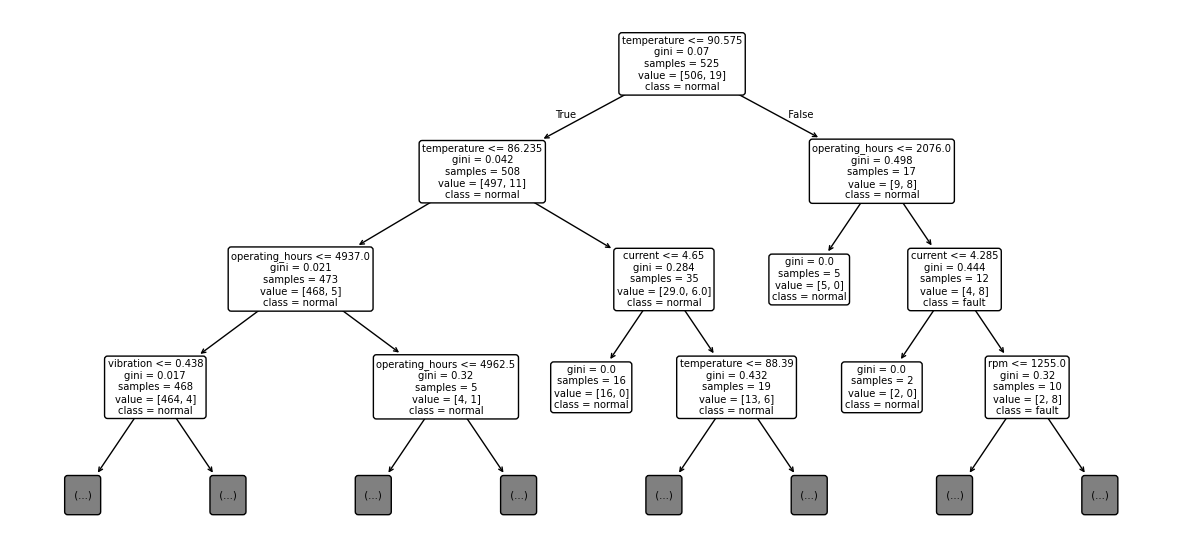

In [21]:
plt.figure(figsize=(15, 7))
plot_tree(
    tree_model,
    feature_names=X_train.columns,
    class_names=["normal", "fault"],
    filled=False,
    rounded=True,
    max_depth=3
)
plt.show()

The purpose is not to declare one algorithm universally better.

Different algorithms can learn different decision structures from the same data.

# Part H: Evaluation

## 17. Why accuracy alone can fail

We will deliberately create an imbalanced fault dataset.

Imagine:

- 990 normal observations
- 10 fault observations

A model that predicts every observation as normal gets 99 percent accuracy, but detects zero faults.

In [22]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

y_imbalanced = np.array([0] * 990 + [1] * 10)
pred_all_normal = np.zeros_like(y_imbalanced)

print("Accuracy:", accuracy_score(y_imbalanced, pred_all_normal))
print("Recall for faults:", recall_score(y_imbalanced, pred_all_normal, zero_division=0))

Accuracy: 0.99
Recall for faults: 0.0


The 99 percent accuracy sounds excellent.

Operationally, the model is useless if its purpose is to detect faults.

This is why evaluation must examine the kinds of mistakes the model makes.

## 18. The confusion matrix

For a binary classification problem:

- **True Positive (TP):** predicted fault, actually fault
- **False Positive (FP):** predicted fault, actually normal
- **False Negative (FN):** predicted normal, actually fault
- **True Negative (TN):** predicted normal, actually normal

For motor monitoring, a false negative can mean a missed fault.

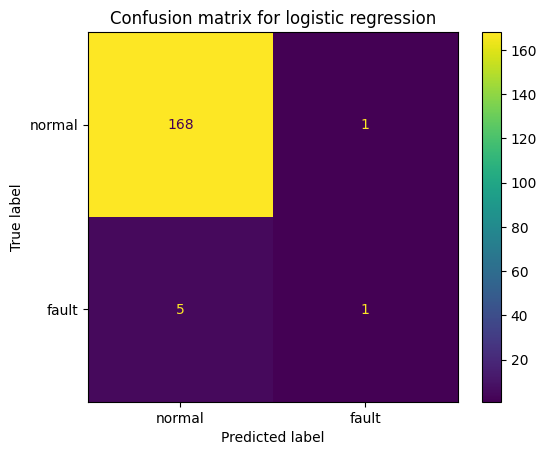

In [23]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    display_labels=["normal", "fault"]
)
plt.title("Confusion matrix for logistic regression")
plt.show()

In [24]:
cm = confusion_matrix(y_test, logistic_predictions)

tn, fp, fn, tp = cm.ravel()

print("True negatives:", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives:", tp)

True negatives: 168
False positives: 1
False negatives: 5
True positives: 1


## 19. Accuracy, precision, recall, and F1

### Accuracy

\[
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
\]

Question:

> What fraction of all predictions were correct?

### Precision

\[
\text{Precision} = \frac{TP}{TP + FP}
\]

Question:

> Of the cases predicted as positive, how many were truly positive?

### Recall

\[
\text{Recall} = \frac{TP}{TP + FN}
\]

Question:

> Of the actual positives, how many did we catch?

### F1 score

\[
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}
{\text{Precision} + \text{Recall}}
\]

F1 summarizes the balance between precision and recall.

In [25]:
metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, logistic_predictions),
    "Precision": precision_score(y_test, logistic_predictions, zero_division=0),
    "Recall": recall_score(y_test, logistic_predictions, zero_division=0),
    "F1": f1_score(y_test, logistic_predictions, zero_division=0)
})

metrics.round(3)

Accuracy     0.966
Precision    0.500
Recall       0.167
F1           0.250
dtype: float64

## 20. Manual metric calculation

Use this confusion matrix:

- TP = 18
- FP = 12
- FN = 2
- TN = 168

Before running the next cell, calculate the metrics yourself.

In [26]:
tp = 18
fp = 12
fn = 2
tn = 168

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1:        {f1:.2%}")

Accuracy:  93.00%
Precision: 60.00%
Recall:    90.00%
F1:        72.00%


Interpretation:

- The model catches most actual faults because recall is high.
- Many predicted alarms are false because precision is lower.
- Whether this is acceptable depends on maintenance cost, safety risk, and human review capacity.

Metrics express which kinds of mistakes matter.

# Part I: Regression metrics

## 21. A small regression problem

We will generate a synthetic house-price dataset.

The target is a number, so this is regression.

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

n_houses = 350

size_m2 = rng.normal(120, 35, n_houses).clip(45, 250)
age_years = rng.uniform(0, 35, n_houses)
distance_km = rng.uniform(1, 25, n_houses)

price_millions = (
    40
    + 1.15 * size_m2
    - 1.25 * age_years
    - 2.2 * distance_km
    + rng.normal(0, 12, n_houses)
)

house_df = pd.DataFrame({
    "size_m2": size_m2,
    "age_years": age_years,
    "distance_km": distance_km,
    "price_UGX_millions": price_millions
})

X_house = house_df.drop(columns="price_UGX_millions")
y_house = house_df["price_UGX_millions"]

Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_house,
    y_house,
    test_size=0.25,
    random_state=42
)

house_model = LinearRegression()
house_model.fit(Xh_train, yh_train)

house_predictions = house_model.predict(Xh_test)

mae = mean_absolute_error(yh_test, house_predictions)
mse = mean_squared_error(yh_test, house_predictions)
rmse = mse ** 0.5
r2 = r2_score(yh_test, house_predictions)

print(f"MAE:  {mae:.2f} million UGX")
print(f"MSE:  {mse:.2f} squared million UGX")
print(f"RMSE: {rmse:.2f} million UGX")
print(f"R^2:  {r2:.3f}")

MAE:  9.25 million UGX
MSE:  128.81 squared million UGX
RMSE: 11.35 million UGX
R^2:  0.939


### Interpreting common regression metrics

**MAE**

Average absolute size of the prediction errors in the original unit.

**MSE**

Squares the errors before averaging. Large mistakes receive a stronger penalty.

**RMSE**

Square root of MSE. It is expressed in the original unit and still gives extra influence to large errors.

**R squared**

Compares the model with a simple mean-based reference.

If RMSE is UGX 10 million, the model's error scale is roughly around UGX 10 million. It does not mean every prediction is wrong by exactly UGX 10 million.

## 22. Residuals

A residual is:

\[
\text{Residual} = \text{Actual} - \text{Predicted}
\]

A positive residual means the actual value was higher than the prediction.

A negative residual means the actual value was lower than the prediction.

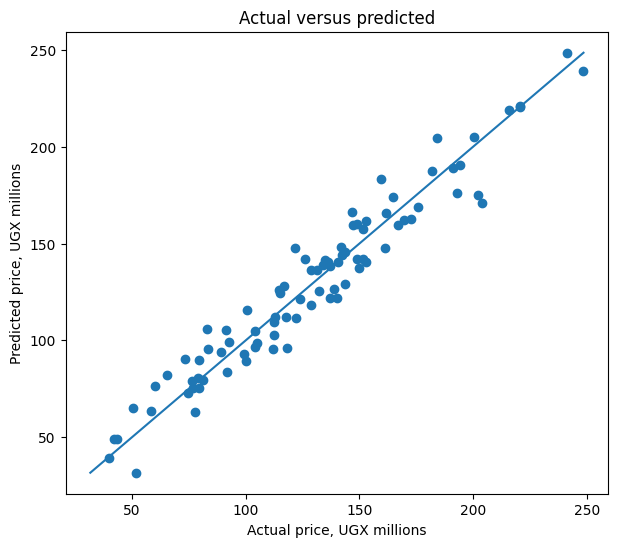

In [28]:
residuals = yh_test.to_numpy() - house_predictions

plt.figure(figsize=(7, 6))
plt.scatter(yh_test, house_predictions)
minimum = min(yh_test.min(), house_predictions.min())
maximum = max(yh_test.max(), house_predictions.max())
plt.plot([minimum, maximum], [minimum, maximum])
plt.xlabel("Actual price, UGX millions")
plt.ylabel("Predicted price, UGX millions")
plt.title("Actual versus predicted")
plt.show()

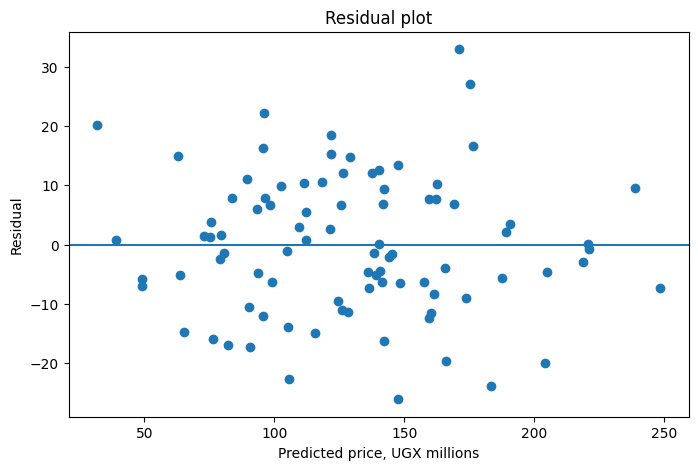

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(house_predictions, residuals)
plt.axhline(0)
plt.xlabel("Predicted price, UGX millions")
plt.ylabel("Residual")
plt.title("Residual plot")
plt.show()

Look for patterns in the residual plot.

A good model does not require residuals to be exactly zero, but systematic patterns can indicate that the model is missing useful structure.

# Part J: Generalisation, underfitting, and overfitting

## 23. Build a noisy nonlinear dataset

We will fit decision trees of different complexity.

The goal is to compare:

1. underfitting
2. reasonable fit
3. overfitting

In [30]:
x_curve = np.linspace(0, 10, 120)
y_curve = np.sin(x_curve) + 0.15 * x_curve + rng.normal(0, 0.22, len(x_curve))

curve_df = pd.DataFrame({"x": x_curve, "y": y_curve})

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    curve_df[["x"]],
    curve_df["y"],
    test_size=0.30,
    random_state=42
)

x_grid = np.linspace(0, 10, 500).reshape(-1, 1)

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


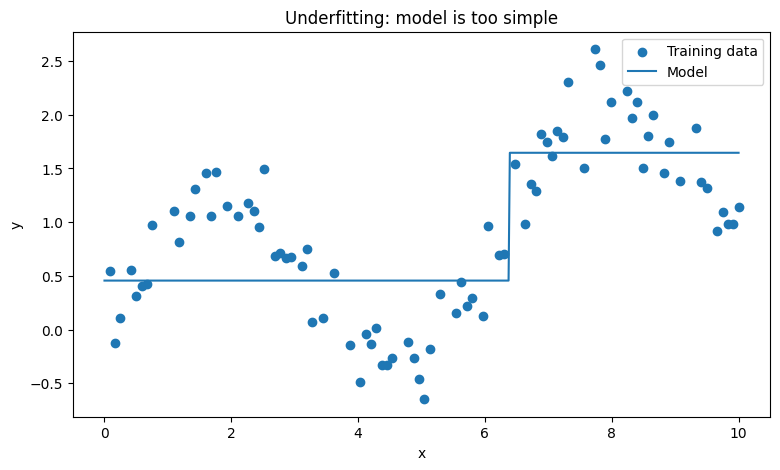

Training R^2: 0.555
Test R^2: 0.566


In [31]:
from sklearn.tree import DecisionTreeRegressor

underfit_model = DecisionTreeRegressor(max_depth=1, random_state=42)
underfit_model.fit(Xc_train, yc_train)

plt.figure(figsize=(9, 5))
plt.scatter(Xc_train["x"], yc_train, label="Training data")
plt.plot(x_grid[:, 0], underfit_model.predict(x_grid), label="Model")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Underfitting: model is too simple")
plt.legend()
plt.show()

print("Training R^2:", round(underfit_model.score(Xc_train, yc_train), 3))
print("Test R^2:", round(underfit_model.score(Xc_test, yc_test), 3))

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


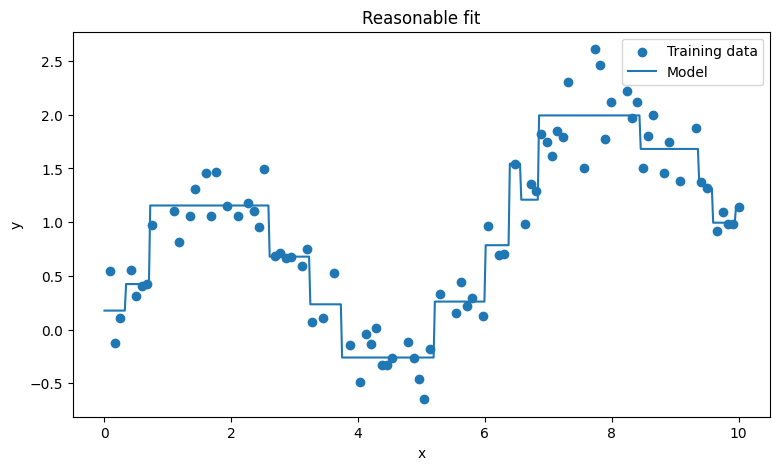

Training R^2: 0.935
Test R^2: 0.902


In [32]:
reasonable_model = DecisionTreeRegressor(max_depth=4, random_state=42)
reasonable_model.fit(Xc_train, yc_train)

plt.figure(figsize=(9, 5))
plt.scatter(Xc_train["x"], yc_train, label="Training data")
plt.plot(x_grid[:, 0], reasonable_model.predict(x_grid), label="Model")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Reasonable fit")
plt.legend()
plt.show()

print("Training R^2:", round(reasonable_model.score(Xc_train, yc_train), 3))
print("Test R^2:", round(reasonable_model.score(Xc_test, yc_test), 3))

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


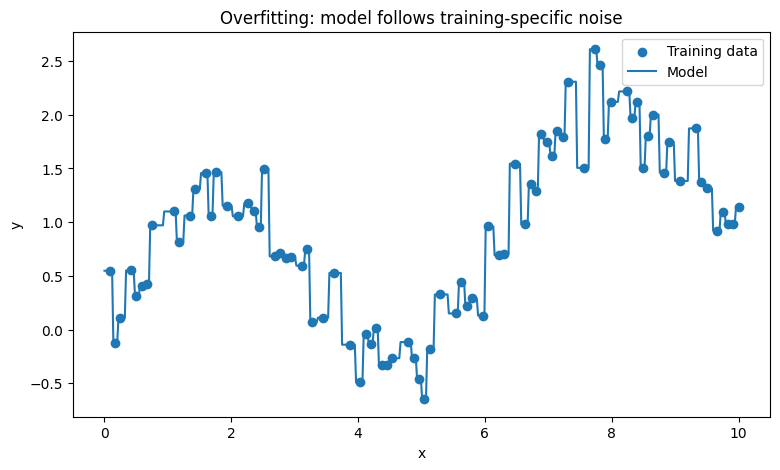

Training R^2: 1.0
Test R^2: 0.827


In [33]:
overfit_model = DecisionTreeRegressor(max_depth=None, random_state=42)
overfit_model.fit(Xc_train, yc_train)

plt.figure(figsize=(9, 5))
plt.scatter(Xc_train["x"], yc_train, label="Training data")
plt.plot(x_grid[:, 0], overfit_model.predict(x_grid), label="Model")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Overfitting: model follows training-specific noise")
plt.legend()
plt.show()

print("Training R^2:", round(overfit_model.score(Xc_train, yc_train), 3))
print("Test R^2:", round(overfit_model.score(Xc_test, yc_test), 3))

### Interpretation

**Underfitting**

- weak training performance
- weak test performance
- model is too simple to capture useful structure

**Reasonable fit**

- good training performance
- similar unseen performance
- useful pattern transfers

**Overfitting**

- extremely strong training performance
- weaker unseen performance
- model follows training-specific noise

More complex does not automatically mean better.

# Part K: Data leakage

## 24. The cheating machine

Suppose a university wants to predict by the end of Week 5 which students may need academic support.

Legitimate Week 5 information might include:

- attendance
- quiz average
- LMS activity
- missed labs

But a **final grade** would not yet exist at Week 5.

If we include final grade, the model can appear excellent because it is using future information.

In [34]:
n_students = 600

attendance_week5 = rng.normal(75, 15, n_students).clip(20, 100)
quiz_average = rng.normal(62, 17, n_students).clip(10, 100)
lms_activity = rng.normal(25, 10, n_students).clip(0, 60)
missed_labs = rng.poisson(1.8, n_students)

support_risk = (
    -0.045 * (attendance_week5 - 75)
    -0.040 * (quiz_average - 62)
    -0.020 * (lms_activity - 25)
    + 0.45 * missed_labs
    + rng.normal(0, 1.0, n_students)
)

needs_support = (support_risk > 1.0).astype(int)

final_grade = (
    0.45 * attendance_week5
    + 0.45 * quiz_average
    + 0.35 * lms_activity
    - 5.0 * missed_labs
    - 28 * needs_support
    + rng.normal(0, 4, n_students)
).clip(0, 100)

student_df = pd.DataFrame({
    "attendance_week5": attendance_week5,
    "quiz_average": quiz_average,
    "lms_activity": lms_activity,
    "missed_labs": missed_labs,
    "final_grade": final_grade,
    "needs_support": needs_support
})

student_df.head()

,attendance_week5,quiz_average,lms_activity,missed_labs,final_grade,needs_support
0,83.312422,68.535300,34.075956,0,78.829929,0
1,63.769765,35.386037,17.358322,4,10.090652,1
2,77.050488,87.841804,25.177510,1,82.053554,0
3,97.356624,53.887487,26.841470,0,51.752312,1
4,62.529515,79.859072,40.471263,2,69.762914,0


In [35]:
legitimate_features = [
    "attendance_week5",
    "quiz_average",
    "lms_activity",
    "missed_labs"
]

leaky_features = legitimate_features + ["final_grade"]

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    student_df,
    student_df["needs_support"],
    test_size=0.25,
    random_state=42,
    stratify=student_df["needs_support"]
)

safe_model = LogisticRegression(max_iter=1000)
safe_model.fit(Xs_train[legitimate_features], ys_train)
safe_pred = safe_model.predict(Xs_test[legitimate_features])

leaky_model = LogisticRegression(max_iter=1000)
leaky_model.fit(Xs_train[leaky_features], ys_train)
leaky_pred = leaky_model.predict(Xs_test[leaky_features])

print("Model using only Week 5 information:")
print("Accuracy:", round(accuracy_score(ys_test, safe_pred), 3))

print("\nModel using final grade:")
print("Accuracy:", round(accuracy_score(ys_test, leaky_pred), 3))

Model using only Week 5 information:
Accuracy: 0.753

Model using final grade:
Accuracy: 1.0


The second model may look better, but it is not a fair Week 5 prediction system.

### The most important leakage question

**Could I know this value at the exact moment the prediction must be made?**

If the honest answer is no, the feature should not be used for that prediction task.

## 25. Common leakage channels

### Target leakage

Information very closely tied to the answer is used as a feature.

Example:

Predict final failure using final grade.

### Future leakage

Information recorded after the prediction time is used.

Example:

Predict Week 5 support need using final exam marks.

### Duplicate or group leakage

The same person, patient, device, or other entity appears in both training and test data in a way that makes the test artificially easy.

### Preprocessing leakage

Scaling, imputation, or other transformations learn from the complete dataset before the split.

## 26. Preprocessing leakage: wrong and correct patterns

### Wrong pattern

```python
scaler.fit(X)
X_scaled = scaler.transform(X)
train_test_split(X_scaled, y)
```

The scaler learned information from all observations, including the future test set.

### Better pattern

```python
X_train, X_test, y_train, y_test = train_test_split(X, y)
scaler.fit(X_train)
```

### Safer scikit-learn pattern

Use a `Pipeline`.

The preprocessing step is then fitted using training data during model fitting.

In [36]:
safe_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

safe_pipeline.fit(X_train, y_train)
pipeline_predictions = safe_pipeline.predict(X_test)

print("Pipeline test accuracy:", round(accuracy_score(y_test, pipeline_predictions), 3))

Pipeline test accuracy: 0.966


# Part L: Validation and cross-validation

## 27. Train, validation, and test sets

During model development, we often need three roles:

- **Training set:** fit model parameters.
- **Validation set:** compare models or hyperparameters during development.
- **Test set:** final held-out evidence after decisions are made.

If you repeatedly check the test set and change the model based on its score, the test set has effectively become another validation set.

In [37]:
X_train_full, X_final_test, y_train_full, y_final_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train2, X_valid, y_train2, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full
)

print("Training rows:", len(X_train2))
print("Validation rows:", len(X_valid))
print("Final test rows:", len(X_final_test))

Training rows: 420
Validation rows: 140
Final test rows: 140


## 28. Cross-validation

A single validation split can be lucky or unlucky.

Cross-validation repeatedly changes which portion acts as the validation fold and averages the scores.

In [38]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

scores = cross_val_score(
    cv_model,
    X,
    y,
    cv=cv,
    scoring="f1"
)

for i, score in enumerate(scores, start=1):
    print(f"Fold {i}: {score:.3f}")

print("\nMean F1:", round(scores.mean(), 3))
print("Standard deviation:", round(scores.std(), 3))

Fold 1: 0.000
Fold 2: 0.000
Fold 3: 0.286
Fold 4: 0.333
Fold 5: 0.500

Mean F1: 0.224
Standard deviation: 0.196


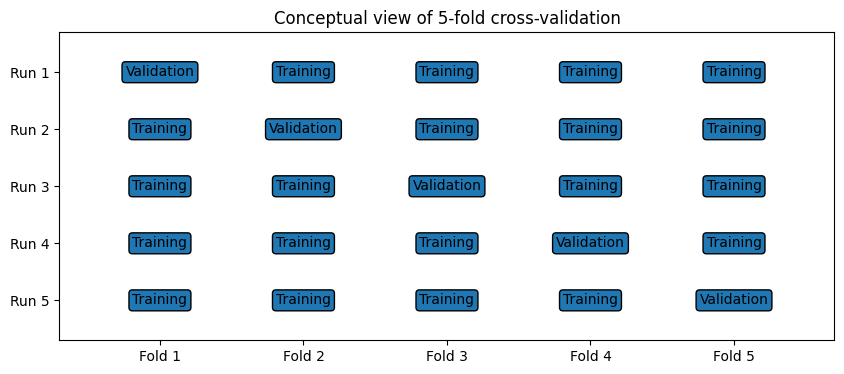

In [39]:
folds = 5

fig, ax = plt.subplots(figsize=(10, 4))
for row in range(folds):
    for col in range(folds):
        label = "Validation" if row == col else "Training"
        ax.text(
            col,
            folds - row,
            label,
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.25")
        )

ax.set_xlim(-0.7, folds - 0.3)
ax.set_ylim(0.3, folds + 0.7)
ax.set_xticks(range(folds))
ax.set_xticklabels([f"Fold {i}" for i in range(1, folds + 1)])
ax.set_yticks(range(1, folds + 1))
ax.set_yticklabels([f"Run {i}" for i in range(folds, 0, -1)])
ax.set_title("Conceptual view of 5-fold cross-validation")
plt.show()

# Part M: Reproducibility and error analysis

## 29. Reproducibility

A good machine learning report should describe enough detail that another person can rebuild the result.

Record:

- dataset or dataset version
- target definition
- feature list
- split logic
- random seed
- preprocessing
- algorithm
- hyperparameters
- evaluation metrics

Keep transformations in code where possible.

`random_state` makes a random process repeatable. It does not magically improve accuracy.

## 30. Do not stop at the score

Error analysis asks what the model got wrong.

Useful questions include:

- Which examples were wrong?
- Are false negatives concentrated in a particular region or subgroup?
- Are errors linked to missing values?
- Are labels questionable?
- Are mistakes near a decision boundary?
- What should a human inspect next?

In [40]:
error_table = X_test.copy()
error_table["actual"] = y_test.to_numpy()
error_table["predicted"] = logistic_predictions
error_table["correct"] = error_table["actual"] == error_table["predicted"]

mistakes = error_table[~error_table["correct"]].copy()

print("Number of test mistakes:", len(mistakes))
display(mistakes.head(10))

Number of test mistakes: 6


,temperature,vibration,current,rpm,operating_hours,actual,predicted,correct
635,72.42,0.573,5.46,1398,4278,1,0,False
248,101.15,0.396,4.64,1645,3570,0,1,False
467,92.44,0.566,5.41,1507,1411,1,0,False
521,67.01,0.505,5.72,1361,3442,1,0,False
654,80.29,0.580,5.13,1590,2740,1,0,False
490,84.77,0.534,5.72,1342,2503,1,0,False


In [41]:
false_negatives = error_table[
    (error_table["actual"] == 1) &
    (error_table["predicted"] == 0)
].copy()

print("False negatives, meaning missed faults:", len(false_negatives))
display(false_negatives.head(10))

False negatives, meaning missed faults: 5


,temperature,vibration,current,rpm,operating_hours,actual,predicted,correct
635,72.42,0.573,5.46,1398,4278,1,0,False
467,92.44,0.566,5.41,1507,1411,1,0,False
521,67.01,0.505,5.72,1361,3442,1,0,False
654,80.29,0.580,5.13,1590,2740,1,0,False
490,84.77,0.534,5.72,1342,2503,1,0,False


Look at the missed faults.

Ask whether they share patterns such as:

- lower temperature than other faults
- borderline vibration
- lower current
- particular operating-hour ranges

A single score cannot reveal these details.

# Part N: A complete mini machine learning workflow

## 31. One compact reference pipeline

The code below brings the major steps together:

1. define features and target
2. split
3. create preprocessing and model pipeline
4. build a baseline
5. train
6. predict
7. evaluate
8. inspect errors

In [42]:
# 1. Features and target
X_full = motor_df.drop(columns="fault")
y_full = motor_df["fault"]

# 2. Split
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full,
    y_full,
    test_size=0.25,
    random_state=42,
    stratify=y_full
)

# 3. Pipeline
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# 4. Baseline
final_baseline = DummyClassifier(strategy="most_frequent")
final_baseline.fit(X_train_full, y_train_full)
baseline_pred = final_baseline.predict(X_test_full)

# 5. Train
final_model.fit(X_train_full, y_train_full)

# 6. Predict
final_pred = final_model.predict(X_test_full)

# 7. Evaluate
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Baseline": [
        accuracy_score(y_test_full, baseline_pred),
        precision_score(y_test_full, baseline_pred, zero_division=0),
        recall_score(y_test_full, baseline_pred, zero_division=0),
        f1_score(y_test_full, baseline_pred, zero_division=0)
    ],
    "Logistic Regression": [
        accuracy_score(y_test_full, final_pred),
        precision_score(y_test_full, final_pred, zero_division=0),
        recall_score(y_test_full, final_pred, zero_division=0),
        f1_score(y_test_full, final_pred, zero_division=0)
    ]
})

display(results.round(3))

# 8. Inspect errors
inspection = X_test_full.copy()
inspection["actual"] = y_test_full.to_numpy()
inspection["predicted"] = final_pred
inspection["error"] = inspection["actual"] != inspection["predicted"]

print("Number of errors:", inspection["error"].sum())
display(inspection[inspection["error"]].head())

,Metric,Baseline,Logistic Regression
0,Accuracy,0.966,0.966
1,Precision,0.000,0.500
2,Recall,0.000,0.167
3,F1,0.000,0.250


Number of errors: 6


,temperature,vibration,current,rpm,operating_hours,actual,predicted,error
635,72.42,0.573,5.46,1398,4278,1,0,True
248,101.15,0.396,4.64,1645,3570,0,1,True
467,92.44,0.566,5.41,1507,1411,1,0,True
521,67.01,0.505,5.72,1361,3442,1,0,True
654,80.29,0.580,5.13,1590,2740,1,0,True


# Part O: Final TODO activities

These are the parts you should complete yourself.

Do not aim only for a high score. Explain what the result means.

## TODO 1: Change the model

Replace logistic regression with `KNeighborsClassifier`.

### Your tasks

1. Import `KNeighborsClassifier`.
2. Build a pipeline with scaling and k-NN.
3. Train it using the same training data.
4. Calculate accuracy, precision, recall, and F1.
5. Compare it with the baseline and logistic regression.
6. Write 2 to 3 sentences explaining whether it improved.

Hint:

```python
from sklearn.neighbors import KNeighborsClassifier
```

In [43]:
# TODO 1

# from sklearn.neighbors import KNeighborsClassifier

# knn_model = Pipeline([
#     ("scaler", StandardScaler()),
#     ("model", KNeighborsClassifier(n_neighbors=5))
# ])

# TODO: fit the model

# TODO: make predictions

# TODO: calculate accuracy, precision, recall, and F1

# TODO: compare with the baseline and logistic

from sklearn.neighbors import KNeighborsClassifier
#Features and Target
x= motor_df
y= motor_df["fault"]

#Split
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

#Pipeline
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

#Baseline
final_baseline = DummyClassifier(strategy="most_frequent")
final_baseline.fit(X_train_full, y_train_full)
baseline_pred = final_baseline.predict(X_test_full)

#Train
final_model.fit(X_train_full, y_train_full)

#Predict
final_pred = final_model.predict(X_test_full)

#Evaluate
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Baseline": [
        accuracy_score(y_test_full, baseline_pred),
        precision_score(y_test_full, baseline_pred, zero_division=0),
        recall_score(y_test_full, baseline_pred, zero_division=0),
        f1_score(y_test_full, baseline_pred, zero_division=0)
        ],
    "KNN": [
        accuracy_score(y_test_full, final_pred),
        precision_score(y_test_full, final_pred, zero_division=0),
        recall_score(y_test_full, final_pred, zero_division=0),
        f1_score(y_test_full, final_pred, zero_division=0)
    ]
})

display(results.round(3))


#Inspect
inspection = X_test_full.copy()
inspection["actual"] = y_test_full.to_numpy()
inspection["predicted"] = final_pred
inspection["error"] = inspection["actual"] != inspection["predicted"]

print("Number of errors:", inspection["error"].sum())
display(inspection[inspection["error"]].head())






,Metric,Baseline,KNN
0,Accuracy,0.966,1.0
1,Precision,0.000,1.0
2,Recall,0.000,1.0
3,F1,0.000,1.0


Number of errors: 0


,temperature,vibration,current,rpm,operating_hours,fault,actual,predicted,error


### TODO 1 reflection

Write your interpretation below.

**My interpretation:**
For Logistic regresssion is having an accuracy of 96.6%, precision of 50%, Recall of 16.7% and F1 is 25% while KNN has 100% of accuracy, precision, Recall and F1.


## TODO 2: Change the classification threshold

Many binary classifiers produce probabilities.

The default decision threshold is often 0.50.

Try thresholds:

- 0.30
- 0.50
- 0.70

For each threshold, calculate precision and recall.

### Question

What happens to precision and recall as the threshold changes?

In [44]:
# TODO 2

probabilities = logistic_model.predict_proba(X_test)[:, 1]

thresholds = [0.30, 0.50, 0.70]

# TODO:
# Loop through the thresholds.
# Convert probabilities to 0 or 1 predictions.
# Calculate precision and recall for each threshold.
# Print the results.

# Example idea:
#
# for threshold in thresholds:
#     threshold_predictions = (probabilities >= threshold).astype(int)
#     ...

### TODO 2 reflection

Which threshold would you choose for a safety-critical motor-fault detector?

Explain why.

...

## TODO 3: Find the leakage

A university wants to predict **by the end of Week 5** which students may need academic support.

Available columns are:

- attendance_week5
- quiz_average
- lms_activity
- programme
- missed_labs
- final_exam_mark
- final_grade
- graduated
- needs_support

### Your tasks

1. Define the prediction unit.
2. Define the target.
3. State the prediction time.
4. List the legitimate features.
5. Identify all obvious leakage variables.
6. Explain why each leaked variable is invalid at Week 5.
7. Suggest an appropriate split strategy.
8. Choose evaluation metrics and justify them.

Use the question:

**Could I know this value at the exact moment the prediction must be made?**

### TODO 3 answer

**Prediction unit:**

...

**Target:**

...

**Prediction time:**

...

**Legitimate features:**

...

**Leakage variables:**

...

**Split strategy:**

...

**Evaluation metrics and justification:**

...

## TODO 4: Would you deploy it?

Consider two equipment-failure models.

| Model | Accuracy | Recall for failures | False alarm rate |
|---|---:|---:|---:|
| Model A | 96% | 65% | 2% |
| Model B | 94% | 94% | 8% |

### Your task

Decide which model, if any, you would deploy.

Your answer must discuss:

1. Which metric matters most and why.
2. The cost of a missed failure.
3. The cost of a false alarm.
4. Whether 94% or 96% accuracy is enough information.
5. What additional evidence you would request.
6. Whether the model should act automatically or keep a human in the loop.

There is no single correct choice. The quality of your reasoning matters.

### TODO 4 answer

**My decision:**

...

**Reasoning:**

...

# Final recap

A trustworthy machine learning workflow is more than:

```python
model.fit(...)
```

A better summary is:

**Frame -> Data -> Audit -> Split -> Prepare -> Baseline -> Train -> Evaluate -> Inspect -> Decide**

Before trusting a claim such as:

> "My AI model achieved 98% accuracy."

ask questions such as:

1. What data was used?
2. What was the baseline?
3. How were training and test data separated?
4. Could there be leakage?
5. Are the classes balanced?
6. Which errors occurred?
7. What are the consequences of false positives and false negatives?
8. Does the model generalise to the intended deployment environment?

The central goal is not to produce a large score.

The goal is to build trustworthy evidence that a model performs usefully on relevant cases it has not seen before.